In [1]:
print("Python environment is working")

Python environment is working


In [1]:
import pandas as pd
from sqlalchemy import create_engine, text, URL
from getpass import getpass

In [ ]:
password = getpass("Enter your PostgreSQL password: ")

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password=password,
    host="localhost",
    port=5432,
    database="customer_churn_portfolio"
)

engine = create_engine(url)

In [8]:
password = getpass("Enter your PostgreSQL password: ")

In [9]:
from sqlalchemy import create_engine, text, URL

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password=password,
    host="localhost",
    port=5432,
    database="customer_churn_portfolio"
)

engine = create_engine(url)

print("Database engine created successfully")

Database engine created successfully


In [10]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT current_database();"))
    print(result.fetchone())

('customer_churn_portfolio',)


In [11]:
query = """
SELECT *
FROM customer_churn_model_features;
"""

df = pd.read_sql(query, engine)

In [12]:
df.shape

(50000, 36)

In [13]:
df.isnull().sum().sort_values(ascending=False)

usage_decline_pct                   5488
login_decline_pct                   5488
customer_id                            0
age                                    0
city                                   0
gender                                 0
state                                  0
customer_segment                       0
plan_category                          0
monthly_fee                            0
acquisition_channel                    0
plan_name                              0
support_level                          0
auto_renew                             0
observation_date                       0
tenure_days                            0
recent_3m_avg_logins                   0
recent_3m_avg_active_days              0
contract_type                          0
data_limit_gb                          0
recent_3m_avg_session_minutes          0
recent_3m_avg_usage_gb                 0
previous_3m_avg_usage_gb               0
previous_3m_avg_logins                 0
recent_3m_failed

In [14]:
df.dtypes

customer_id                           int64
age                                   int64
gender                                  str
city                                    str
state                                   str
customer_segment                        str
acquisition_channel                     str
plan_name                               str
plan_category                           str
monthly_fee                         float64
contract_type                           str
data_limit_gb                       float64
support_level                           str
auto_renew                             bool
observation_date                     object
tenure_days                           int64
recent_3m_avg_logins                float64
recent_3m_avg_active_days           float64
recent_3m_avg_usage_gb              float64
recent_3m_avg_session_minutes       float64
previous_3m_avg_logins              float64
previous_3m_avg_usage_gb            float64
login_decline_pct               

In [15]:
df["churned"].value_counts()

churned
0    39858
1    10142
Name: count, dtype: int64

In [16]:
df.isnull().sum().sort_values(ascending=False)

usage_decline_pct                   5488
login_decline_pct                   5488
customer_id                            0
age                                    0
city                                   0
gender                                 0
state                                  0
customer_segment                       0
plan_category                          0
monthly_fee                            0
acquisition_channel                    0
plan_name                              0
support_level                          0
auto_renew                             0
observation_date                       0
tenure_days                            0
recent_3m_avg_logins                   0
recent_3m_avg_active_days              0
contract_type                          0
data_limit_gb                          0
recent_3m_avg_session_minutes          0
recent_3m_avg_usage_gb                 0
previous_3m_avg_usage_gb               0
previous_3m_avg_logins                 0
recent_3m_failed

In [17]:
df["has_6m_history"] = (
    df["previous_3m_avg_logins"] > 0
).astype(int)

df["login_decline_pct"] = df["login_decline_pct"].fillna(0)
df["usage_decline_pct"] = df["usage_decline_pct"].fillna(0)

In [19]:
df["churned"].value_counts()

churned
0    39858
1    10142
Name: count, dtype: int64

In [22]:
# Target variable
y = df["churned"]

# Features
X = df.drop(
    columns=[
        "customer_id",
        "observation_date",
        "churned"
    ]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 34)
y shape: (50000,)


In [ ]:
X.dtypes

age                                   int64
gender                                  str
city                                    str
state                                   str
customer_segment                        str
acquisition_channel                     str
plan_name                               str
plan_category                           str
monthly_fee                         float64
contract_type                           str
data_limit_gb                       float64
support_level                           str
auto_renew                             bool
tenure_days                           int64
recent_3m_avg_logins                float64
recent_3m_avg_active_days           float64
recent_3m_avg_usage_gb              float64
recent_3m_avg_session_minutes       float64
previous_3m_avg_logins              float64
previous_3m_avg_usage_gb            float64
login_decline_pct                   float64
usage_decline_pct                   float64
recent_3m_failed_payments       

In [24]:
X["auto_renew"] = X["auto_renew"].astype(int)

In [25]:
categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical columns:", len(numerical_cols))
print(numerical_cols)

Categorical columns: 9
['gender', 'city', 'state', 'customer_segment', 'acquisition_channel', 'plan_name', 'plan_category', 'contract_type', 'support_level']

Numerical columns: 25
['age', 'monthly_fee', 'data_limit_gb', 'auto_renew', 'tenure_days', 'recent_3m_avg_logins', 'recent_3m_avg_active_days', 'recent_3m_avg_usage_gb', 'recent_3m_avg_session_minutes', 'previous_3m_avg_logins', 'previous_3m_avg_usage_gb', 'login_decline_pct', 'usage_decline_pct', 'recent_3m_failed_payments', 'recent_3m_overdue_payments', 'recent_3m_partial_payments', 'recent_3m_avg_days_late', 'recent_3m_avg_payment_attempts', 'recent_90d_tickets', 'recent_90d_high_priority_tickets', 'recent_90d_repeat_contacts', 'recent_90d_unresolved_tickets', 'recent_90d_avg_resolution_hours', 'recent_90d_avg_satisfaction', 'has_6m_history']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 40000
Testing rows: 10000


In [27]:
print("Training churn rate:")
print(y_train.value_counts(normalize=True))

print("\nTesting churn rate:")
print(y_test.value_counts(normalize=True))

Training churn rate:
churned
0    0.79715
1    0.20285
Name: proportion, dtype: float64

Testing churn rate:
churned
0    0.7972
1    0.2028
Name: proportion, dtype: float64


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9448
Precision: 0.9077
Recall: 0.8102
F1 Score: 0.8562
ROC AUC: 0.9637

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      7972
           1       0.91      0.81      0.86      2028

    accuracy                           0.94     10000
   macro avg       0.93      0.89      0.91     10000
weighted avg       0.94      0.94      0.94     10000



Matplotlib is building the font cache; this may take a moment.


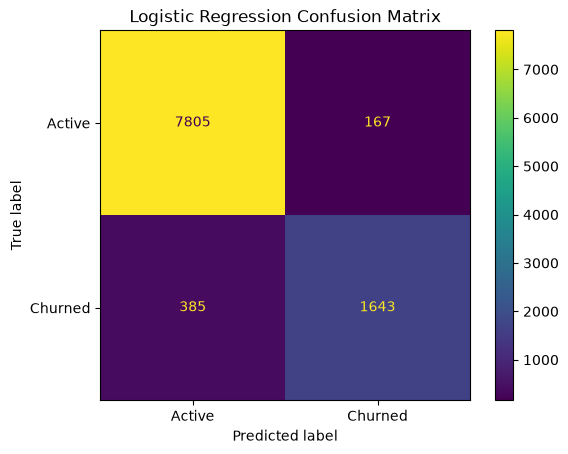

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Active", "Churned"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [33]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Random Forest Precision:", round(precision_score(y_test, rf_pred), 4))
print("Random Forest Recall:", round(recall_score(y_test, rf_pred), 4))
print("Random Forest F1 Score:", round(f1_score(y_test, rf_pred), 4))
print("Random Forest ROC AUC:", round(roc_auc_score(y_test, rf_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9429
Random Forest Precision: 0.826
Random Forest Recall: 0.9103
Random Forest F1 Score: 0.8661
Random Forest ROC AUC: 0.9799

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      7972
           1       0.83      0.91      0.87      2028

    accuracy                           0.94     10000
   macro avg       0.90      0.93      0.91     10000
weighted avg       0.95      0.94      0.94     10000



In [34]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9448,0.9077,0.8102,0.8562,0.9637
1,Random Forest,0.9429,0.8260,0.9103,0.8661,0.9799


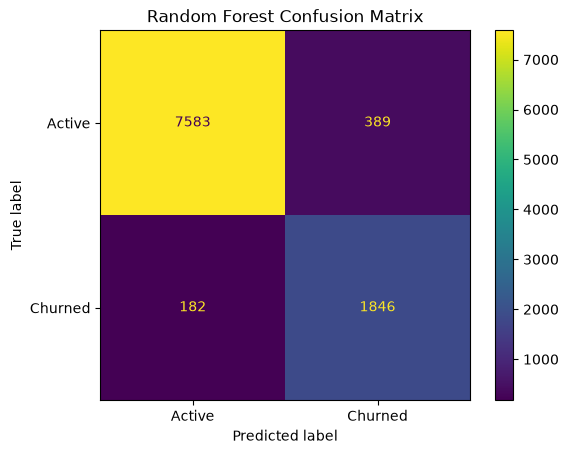

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_pred)

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Active", "Churned"]
)

rf_disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [36]:
# Get the fitted preprocessing step
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importance values
importances = random_forest_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Importance
0,num__recent_90d_avg_resolution_hours,0.234237
1,num__recent_90d_avg_satisfaction,0.144032
2,num__recent_90d_tickets,0.101243
3,num__recent_90d_high_priority_tickets,0.084414
4,num__recent_90d_repeat_contacts,0.079462
5,num__recent_3m_avg_logins,0.069133
6,num__recent_3m_avg_active_days,0.049605
7,num__tenure_days,0.048763
8,num__login_decline_pct,0.040656
9,num__recent_3m_avg_session_minutes,0.028979


In [37]:
top_features = feature_importance.head(15).copy()

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

top_features

,Feature,Importance
0,Recent 90D Avg Resolution Hours,0.234237
1,Recent 90D Avg Satisfaction,0.144032
2,Recent 90D Tickets,0.101243
3,Recent 90D High Priority Tickets,0.084414
4,Recent 90D Repeat Contacts,0.079462
5,Recent 3M Avg Logins,0.069133
6,Recent 3M Avg Active Days,0.049605
7,Tenure Days,0.048763
8,Login Decline Pct,0.040656
9,Recent 3M Avg Session Minutes,0.028979


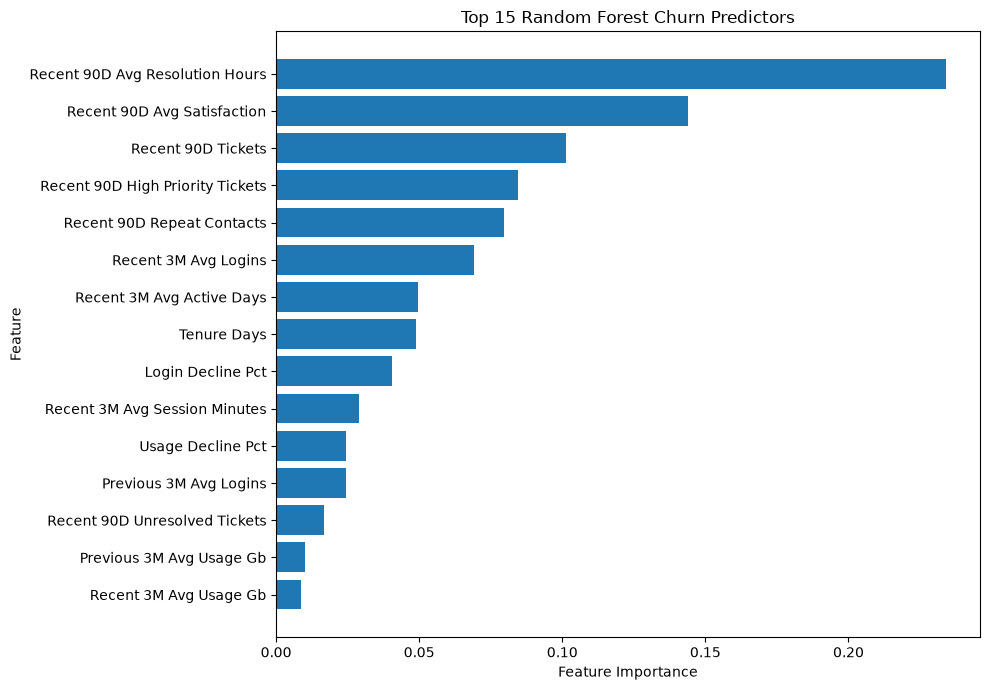

In [38]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Churn Predictors")

plt.tight_layout()
plt.show()

In [39]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(y_test, rf_prob)

prob_true, prob_pred = calibration_curve(
    y_test,
    rf_prob,
    n_bins=10,
    strategy="quantile"
)

print("Brier Score:", round(brier_score, 4))

calibration_df = pd.DataFrame({
    "Predicted Probability": prob_pred,
    "Actual Churn Rate": prob_true
})

calibration_df.round(4)

Brier Score: 0.0501


,Predicted Probability,Actual Churn Rate
0,0.0149,0.000
1,0.0294,0.001
2,0.0454,0.002
3,0.0675,0.004
4,0.1020,0.014
5,0.1566,0.025
6,0.2470,0.055
7,0.4290,0.141
8,0.7958,0.790
9,0.9755,0.996


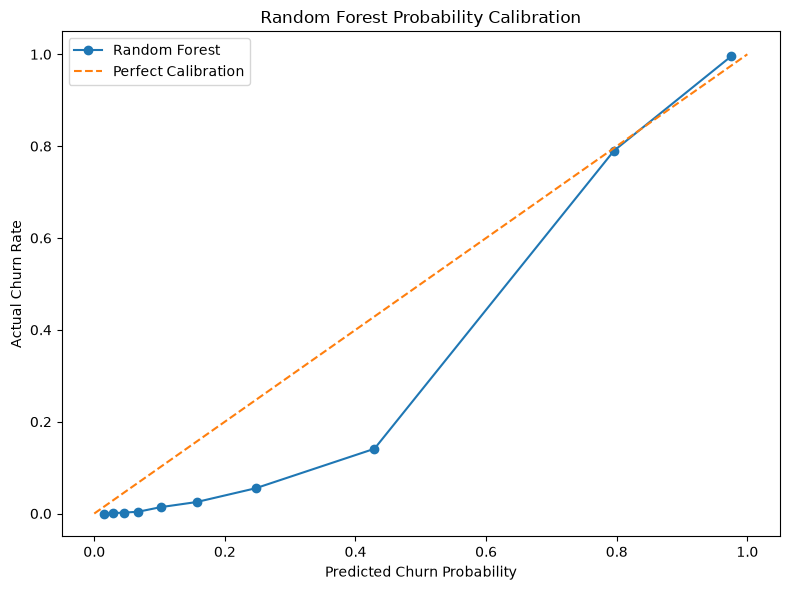

In [40]:
plt.figure(figsize=(8, 6))

plt.plot(
    calibration_df["Predicted Probability"],
    calibration_df["Actual Churn Rate"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Actual Churn Rate")
plt.title("Random Forest Probability Calibration")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    estimator=random_forest_model,
    method="sigmoid",
    cv=5
)

calibrated_rf.fit(X_train, y_train)

print("Calibrated Random Forest trained successfully")

Calibrated Random Forest trained successfully


In [42]:
cal_rf_pred = calibrated_rf.predict(X_test)
cal_rf_prob = calibrated_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, cal_rf_pred), 4))
print("Precision:", round(precision_score(y_test, cal_rf_pred), 4))
print("Recall:", round(recall_score(y_test, cal_rf_pred), 4))
print("F1 Score:", round(f1_score(y_test, cal_rf_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, cal_rf_prob), 4))
print(
    "Brier Score:",
    round(brier_score_loss(y_test, cal_rf_prob), 4)
)

Accuracy: 0.9545
Precision: 0.897
Recall: 0.8762
F1 Score: 0.8865
ROC AUC: 0.9796
Brier Score: 0.0348


In [43]:
active_mask = df["churned"] == 0

active_X = X.loc[active_mask].copy()

active_probabilities = calibrated_rf.predict_proba(active_X)[:, 1]

active_predictions = pd.DataFrame({
    "customer_id": df.loc[active_mask, "customer_id"].values,
    "churn_probability": active_probabilities
})

active_predictions.head()

,customer_id,churn_probability
0,5468,0.004951
1,176,0.004120
2,4683,0.003940
3,1003,0.005765
4,5722,0.022244


In [44]:
active_predictions["churn_probability"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    39858.000000
mean         0.040684
std          0.112066
min          0.003107
25%          0.004244
50%          0.006594
75%          0.018255
90%          0.081938
95%          0.213626
99%          0.668126
max          0.979433
Name: churn_probability, dtype: float64

In [45]:
def assign_risk_band(probability):
    if probability >= 0.50:
        return "Critical"
    elif probability >= 0.20:
        return "High"
    elif probability >= 0.05:
        return "Medium"
    else:
        return "Low"


active_predictions["risk_band"] = (
    active_predictions["churn_probability"]
    .apply(assign_risk_band)
)

active_predictions["predicted_churn"] = (
    active_predictions["churn_probability"] >= 0.50
).astype(int)

active_predictions.head()

,customer_id,churn_probability,risk_band,predicted_churn
0,5468,0.004951,Low,0
1,176,0.004120,Low,0
2,4683,0.003940,Low,0
3,1003,0.005765,Low,0
4,5722,0.022244,Low,0


In [46]:
risk_summary = (
    active_predictions["risk_band"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"])
)

risk_summary

risk_band
Low         34404
Medium       3341
High         1368
Critical      745
Name: count, dtype: int64

In [47]:
(
    active_predictions["risk_band"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High", "Critical"])
    * 100
).round(2)

risk_band
Low         86.32
Medium       8.38
High         3.43
Critical     1.87
Name: proportion, dtype: float64

In [48]:
active_predictions["prediction_date"] = pd.to_datetime("2026-08-31")
active_predictions["model_version"] = "calibrated_random_forest_v1"

# PostgreSQL column order
predictions_to_save = active_predictions[
    [
        "customer_id",
        "prediction_date",
        "churn_probability",
        "predicted_churn",
        "risk_band",
        "model_version"
    ]
].copy()

# Match PostgreSQL NUMERIC(6,5)
predictions_to_save["churn_probability"] = (
    predictions_to_save["churn_probability"].round(5)
)

predictions_to_save.head()

,customer_id,prediction_date,churn_probability,predicted_churn,risk_band,model_version
0,5468,2026-08-31,0.00495,0,Low,calibrated_random_forest_v1
1,176,2026-08-31,0.00412,0,Low,calibrated_random_forest_v1
2,4683,2026-08-31,0.00394,0,Low,calibrated_random_forest_v1
3,1003,2026-08-31,0.00576,0,Low,calibrated_random_forest_v1
4,5722,2026-08-31,0.02224,0,Low,calibrated_random_forest_v1


In [49]:
print(predictions_to_save.shape)

(39858, 6)


In [50]:
predictions_to_save.to_sql(
    "churn_predictions",
    engine,
    if_exists="append",
    index=False,
    method="multi",
    chunksize=1000
)

print("Predictions written to PostgreSQL successfully")

Predictions written to PostgreSQL successfully


In [51]:
check_query = """
SELECT
    risk_band,
    COUNT(*) AS customers,
    ROUND(AVG(churn_probability) * 100, 2) AS avg_churn_probability_pct
FROM churn_predictions
GROUP BY risk_band
ORDER BY
    CASE risk_band
        WHEN 'Critical' THEN 1
        WHEN 'High' THEN 2
        WHEN 'Medium' THEN 3
        WHEN 'Low' THEN 4
    END;
"""

pd.read_sql(check_query, engine)

,risk_band,customers,avg_churn_probability_pct
0,Critical,745,69.12
1,High,1368,32.40
2,Medium,3341,10.01
3,Low,34404,0.96


In [53]:
model_performance = pd.DataFrame({
    "model_name": [
        "Logistic Regression",
        "Random Forest",
        "Calibrated Random Forest"
    ],
    "accuracy": [
        0.9448,
        0.9429,
        0.9545
    ],
    "precision": [
        0.9077,
        0.8260,
        0.8970
    ],
    "recall": [
        0.8102,
        0.9103,
        0.8762
    ],
    "f1_score": [
        0.8562,
        0.8661,
        0.8865
    ],
    "roc_auc": [
        0.9637,
        0.9799,
        0.9796
    ],
    "brier_score": [
        None,
        None,
        0.0348
    ],
    "test_customers": [
        10000,
        10000,
        10000
    ]
})

model_performance

,model_name,accuracy,precision,recall,f1_score,roc_auc,brier_score,test_customers
0,Logistic Regression,0.9448,0.9077,0.8102,0.8562,0.9637,NaN,10000
1,Random Forest,0.9429,0.8260,0.9103,0.8661,0.9799,NaN,10000
2,Calibrated Random Forest,0.9545,0.8970,0.8762,0.8865,0.9796,0.0348,10000


In [54]:
model_performance.to_sql(
    "model_performance",
    engine,
    if_exists="replace",
    index=False
)

print("Model performance saved to PostgreSQL")

Model performance saved to PostgreSQL


In [55]:
pd.read_sql(
    """
    SELECT *
    FROM model_performance
    ORDER BY f1_score DESC;
    """,
    engine
)

,model_name,accuracy,precision,recall,f1_score,roc_auc,brier_score,test_customers
0,Calibrated Random Forest,0.9545,0.8970,0.8762,0.8865,0.9796,0.0348,10000
1,Random Forest,0.9429,0.8260,0.9103,0.8661,0.9799,NaN,10000
2,Logistic Regression,0.9448,0.9077,0.8102,0.8562,0.9637,NaN,10000


In [56]:
from sklearn.metrics import confusion_matrix

cal_cm = confusion_matrix(y_test, cal_rf_pred)

confusion_matrix_df = pd.DataFrame({
    "actual_class": [
        "Active",
        "Active",
        "Churned",
        "Churned"
    ],
    "predicted_class": [
        "Active",
        "Churned",
        "Active",
        "Churned"
    ],
    "customer_count": [
        cal_cm[0, 0],
        cal_cm[0, 1],
        cal_cm[1, 0],
        cal_cm[1, 1]
    ],
    "model_name": "Calibrated Random Forest"
})

confusion_matrix_df

,actual_class,predicted_class,customer_count,model_name
0,Active,Active,7768,Calibrated Random Forest
1,Active,Churned,204,Calibrated Random Forest
2,Churned,Active,251,Calibrated Random Forest
3,Churned,Churned,1777,Calibrated Random Forest


In [57]:
confusion_matrix_df.to_sql(
    "model_confusion_matrix",
    engine,
    if_exists="replace",
    index=False
)

print("Confusion matrix saved to PostgreSQL")

Confusion matrix saved to PostgreSQL


In [58]:
pd.read_sql(
    "SELECT * FROM model_confusion_matrix;",
    engine
)

,actual_class,predicted_class,customer_count,model_name
0,Active,Active,7768,Calibrated Random Forest
1,Active,Churned,204,Calibrated Random Forest
2,Churned,Active,251,Calibrated Random Forest
3,Churned,Churned,1777,Calibrated Random Forest


In [59]:
top_predictors_db = feature_importance.head(15).copy()

top_predictors_db["feature_name"] = (
    top_predictors_db["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

top_predictors_db = top_predictors_db[
    ["feature_name", "Importance"]
].rename(
    columns={"Importance": "importance"}
)

top_predictors_db["rank"] = range(1, len(top_predictors_db) + 1)
top_predictors_db["model_name"] = "Random Forest"

top_predictors_db

,feature_name,importance,rank,model_name
0,Recent 90D Avg Resolution Hours,0.234237,1,Random Forest
1,Recent 90D Avg Satisfaction,0.144032,2,Random Forest
2,Recent 90D Tickets,0.101243,3,Random Forest
3,Recent 90D High Priority Tickets,0.084414,4,Random Forest
4,Recent 90D Repeat Contacts,0.079462,5,Random Forest
5,Recent 3M Avg Logins,0.069133,6,Random Forest
6,Recent 3M Avg Active Days,0.049605,7,Random Forest
7,Tenure Days,0.048763,8,Random Forest
8,Login Decline Pct,0.040656,9,Random Forest
9,Recent 3M Avg Session Minutes,0.028979,10,Random Forest


In [60]:
top_predictors_db.to_sql(
    "model_feature_importance",
    engine,
    if_exists="replace",
    index=False
)

print("Feature importance saved to PostgreSQL")

Feature importance saved to PostgreSQL


In [61]:
pd.read_sql(
    """
    SELECT *
    FROM model_feature_importance
    ORDER BY rank;
    """,
    engine
)

,feature_name,importance,rank,model_name
0,Recent 90D Avg Resolution Hours,0.234237,1,Random Forest
1,Recent 90D Avg Satisfaction,0.144032,2,Random Forest
2,Recent 90D Tickets,0.101243,3,Random Forest
3,Recent 90D High Priority Tickets,0.084414,4,Random Forest
4,Recent 90D Repeat Contacts,0.079462,5,Random Forest
5,Recent 3M Avg Logins,0.069133,6,Random Forest
6,Recent 3M Avg Active Days,0.049605,7,Random Forest
7,Tenure Days,0.048763,8,Random Forest
8,Login Decline Pct,0.040656,9,Random Forest
9,Recent 3M Avg Session Minutes,0.028979,10,Random Forest
